In [69]:

# # Model Analysis
# 
# This notebook visualizes the dataset, compares different models qualitative reconstructions, and analyzes quantitative metrics (MSE, PSNR, SSIM).

In [20]:
a = (2480 - 1840)/1800
b = 100 * a
print(f"{b:.2f}%")

35.56%


In [70]:


import os
import sys
from pathlib import Path

# Add the project root to path so we can import src_2D
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
import numpy as np

from src_2D.data.dataset_2d import SinogramCompletionDataset
from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
from src_2D.models.Unet2D.evaluate_2d import plot_qualitative_example, resolve_compute_device
from src_2D.models.Unet2D.evaluate_2d import build_full_astra_geometries, reconstruct_volume_fbp

from src_2D.models.Interpolation.interpolator_2d import LinearViewInterpolator, SinusoidalViewInterpolator
from src_2D.models.Unet2D.unet_2d import SinogramUNet


# ## 1. Quantitative Analysis: Metrics comparison
# 
# First, make sure you have run the `src_2D/evaluate_all.py` script to generate the metrics CSV.

,Model,MSE,PSNR,SSIM
0,LinearInterpolation,0.015418,12.737849,0.552000
1,SinusoidalInterpolation,0.021552,11.260913,0.354461
2,UNet2D,0.002522,18.911613,0.558930
3,UNet2dHLCC,0.002270,20.153897,0.480945
4,UNet2dRNO,0.057922,5.640717,0.130110


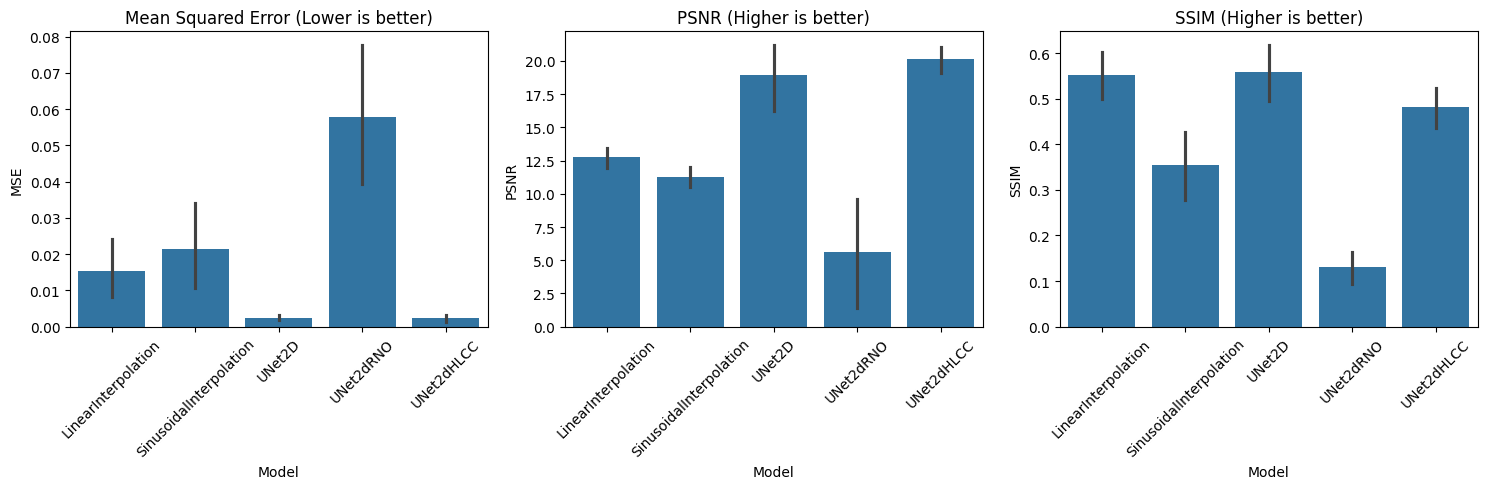

In [71]:


metrics_path = project_root / 'outputs' / 'evaluation' / 'model_comparison_metrics.csv'
if metrics_path.exists():
    df = pd.read_csv(metrics_path)
    
    from IPython.display import display
    
    # Aggregate metrics
    summary = df.groupby('Model')[['MSE', 'PSNR', 'SSIM']].mean().reset_index()
    display(summary)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.barplot(data=df, x='Model', y='MSE', ax=axes[0]).set_title('Mean Squared Error (Lower is better)')
    sns.barplot(data=df, x='Model', y='PSNR', ax=axes[1]).set_title('PSNR (Higher is better)')
    sns.barplot(data=df, x='Model', y='SSIM', ax=axes[2]).set_title('SSIM (Higher is better)')
    
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()
else:
    print(f"Metrics file not found at {metrics_path}. Please run src_2D/evaluate_all.py first.")


# ## 2. Qualitative Analysis: Visual Comparison of Model Reconstructions
# 
# Here we visualize how Linear Interpolation, Sinusoidal Interpolation, and UNet complete the incomplete signal on 10 random samples from the dataset, and also run the BP reconstruction to see the resulting image.

In [72]:


device = resolve_compute_device()

# 1. Initialize models
models = {}

# Sinusoidal
models['Sinusoidal'] = SinusoidalViewInterpolator().to(device)
models['Sinusoidal'].eval()

# UNet2D
unet = SinogramUNet(in_channels=1, out_channels=1, filters=32).to(device)
unet_weights_path = project_root / 'outputs' / '2d' / 'checkpoints' / 'best_model.pt'
if unet_weights_path.exists():
    try:
        state_dict = torch.load(unet_weights_path, map_location=device, weights_only=True)
        new_state_dict = {}
        for k, v in state_dict.items():
            name = k.replace("module.", "") if k.startswith("module.") else k
            new_state_dict[name] = v
        unet.load_state_dict(new_state_dict)
        unet.eval()
        models['UNet2D'] = unet
        print("Successfully loaded UNet2D weights.")
    except Exception as e:
        print(f"Failed to load UNet weights: {e}")

# UNet2dRNO
from src_2D.models.Unet2dRNO.unet_rno import RadonInformedUNet
from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
geometry = DBTGeometryConfig()
unet_rno = RadonInformedUNet(geometry_config=geometry, in_channels=1, out_channels=1, filters=32).to(device)
rno_weights_path = project_root / 'outputs' / '2d' / 'checkpoints_rno' / 'best_model.pt'
if rno_weights_path.exists():
    try:
        state_dict = torch.load(rno_weights_path, map_location=device, weights_only=True)
        new_state_dict = {}
        for k, v in state_dict.items():
            name = k.replace("module.", "") if k.startswith("module.") else k
            new_state_dict[name] = v
        unet_rno.load_state_dict(new_state_dict)
        unet_rno.eval()
        models['UNet2dRNO'] = unet_rno
        print("Successfully loaded UNet2dRNO weights.")
    except Exception as e:
        print(f"Failed to load UNet2dRNO weights: {e}")

# UNet2dHLCC
from src_2D.models.Unet2dHLCC.unet_hlcc import Unet2dHLCC
unet_hlcc = Unet2dHLCC(in_channels=1, out_channels=1, filters=32).to(device)
hlcc_weights_path = project_root / 'outputs' / '2d' / 'checkpoints_unet2dhlcc' / 'best_unet2dhlcc_model.pt'
if hlcc_weights_path.exists():
    try:
        state_dict = torch.load(hlcc_weights_path, map_location=device, weights_only=True)
        new_state_dict = {}
        for k, v in state_dict.items():
            name = k.replace('module.', '') if k.startswith('module.') else k
            new_state_dict[name] = v
        unet_hlcc.load_state_dict(new_state_dict)
        unet_hlcc.eval()
        models['UNet2dHLCC'] = unet_hlcc
        print('Successfully loaded UNet2dHLCC weights.')
    except Exception as e:
        print(f'Failed to load UNet2dHLCC weights: {e}')

Successfully loaded UNet2D weights.
Successfully loaded UNet2dRNO weights.
Successfully loaded UNet2dHLCC weights.


Running BP Reconstructions for Sample 1...


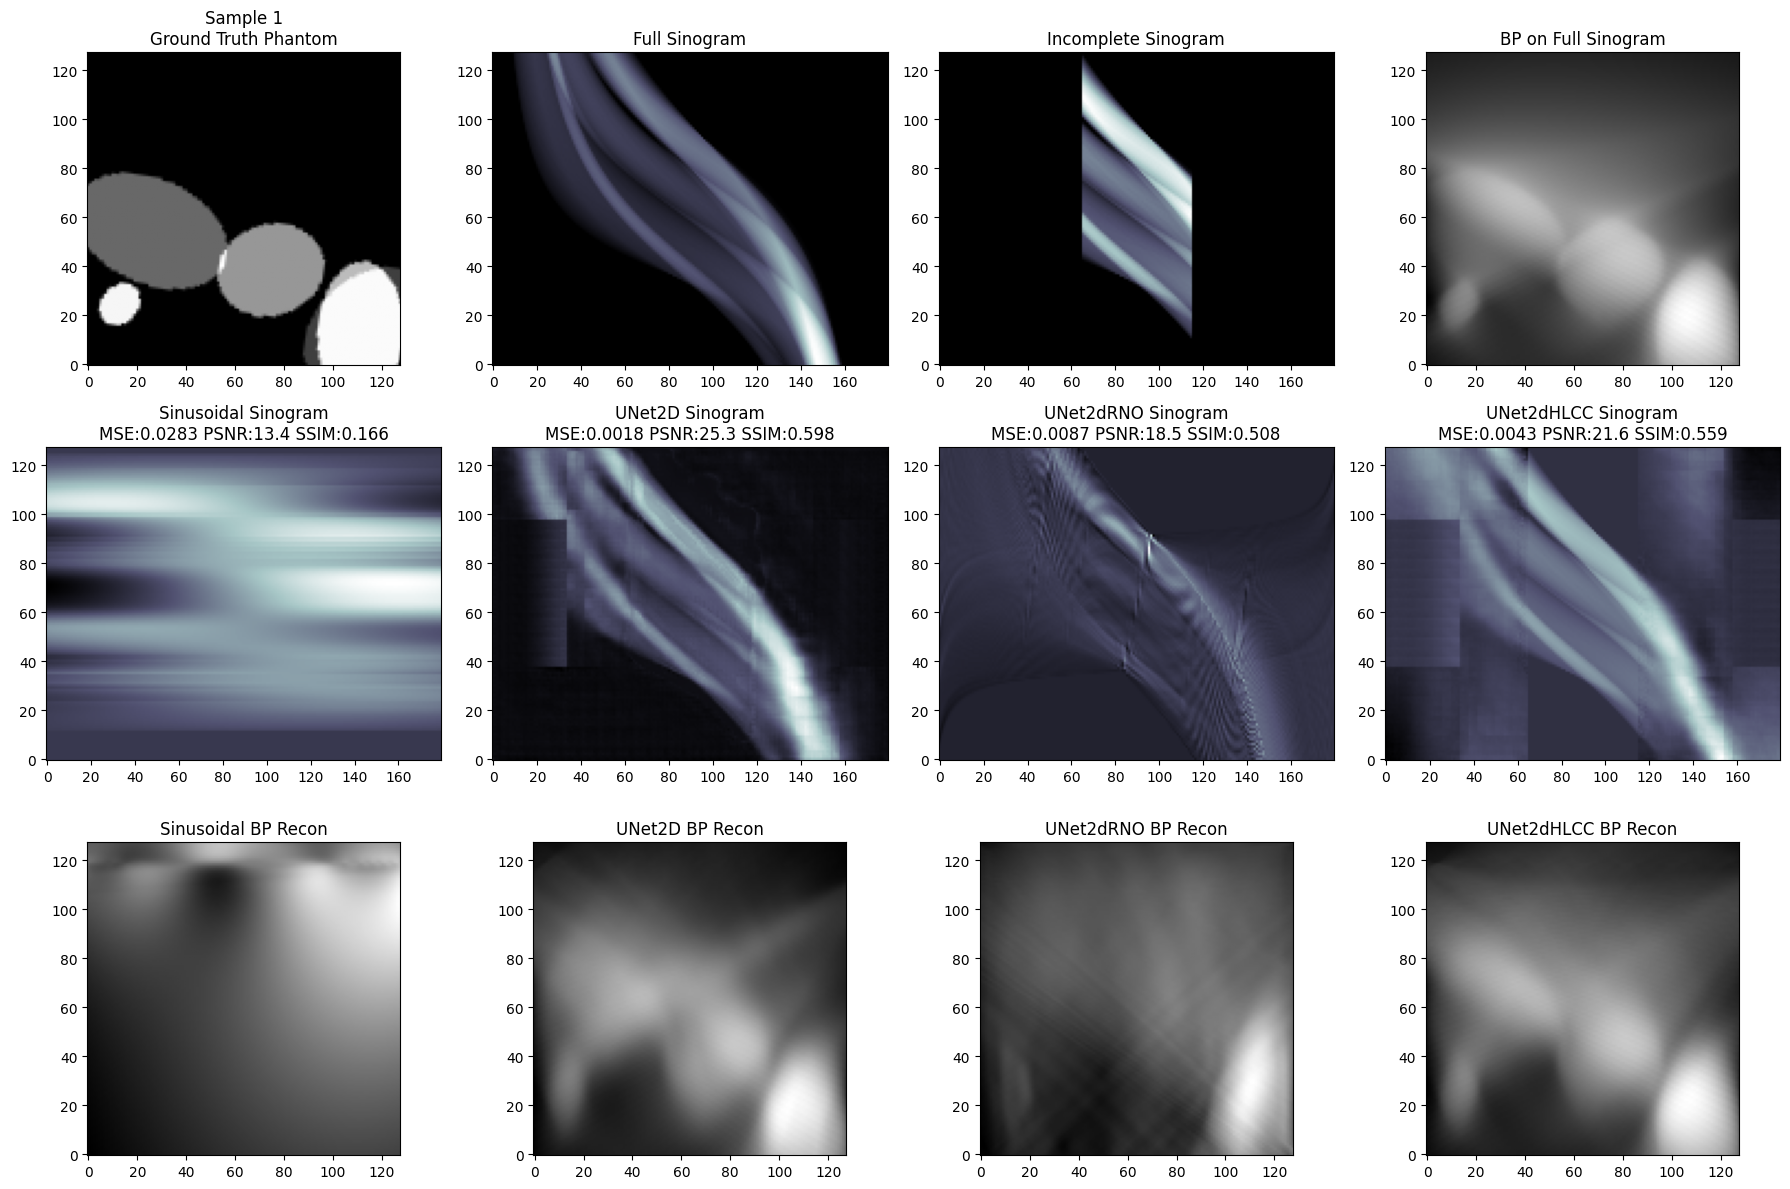

Running BP Reconstructions for Sample 2...


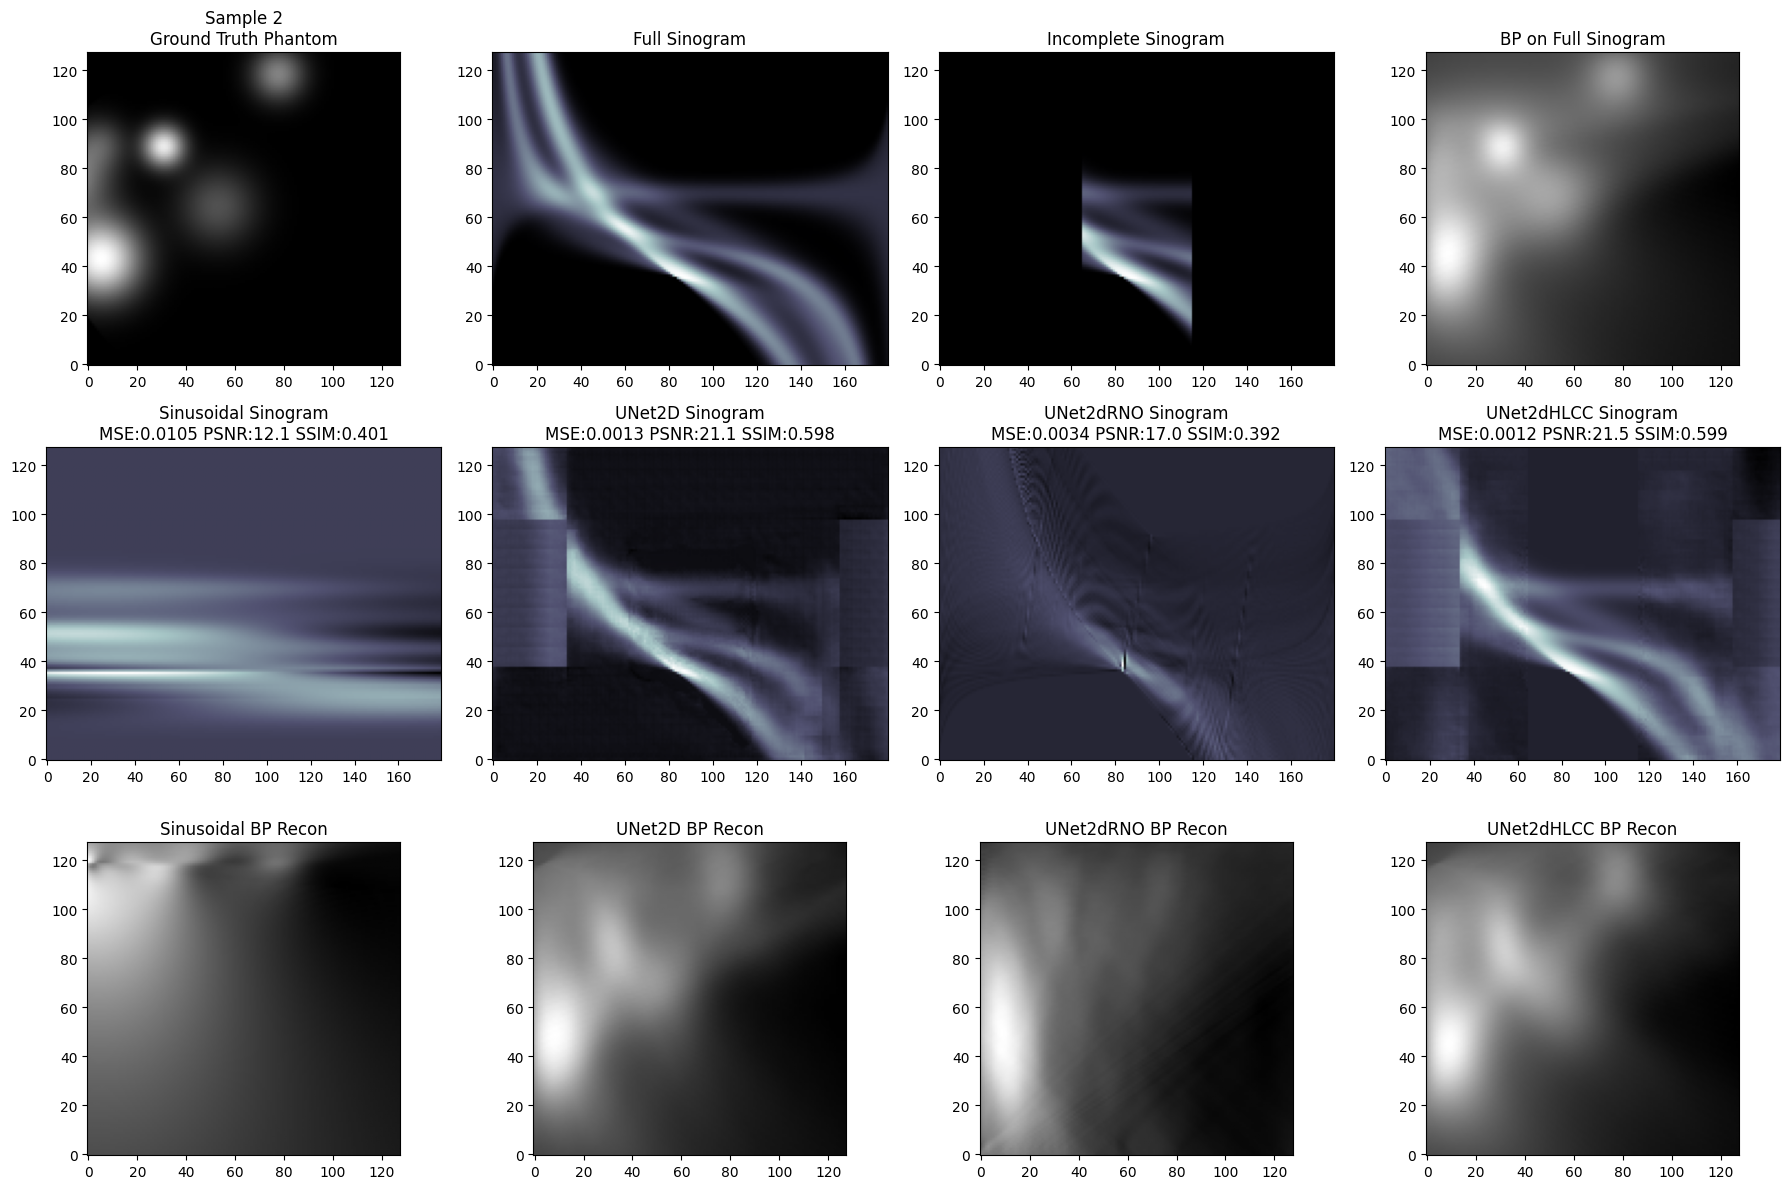

Running BP Reconstructions for Sample 3...


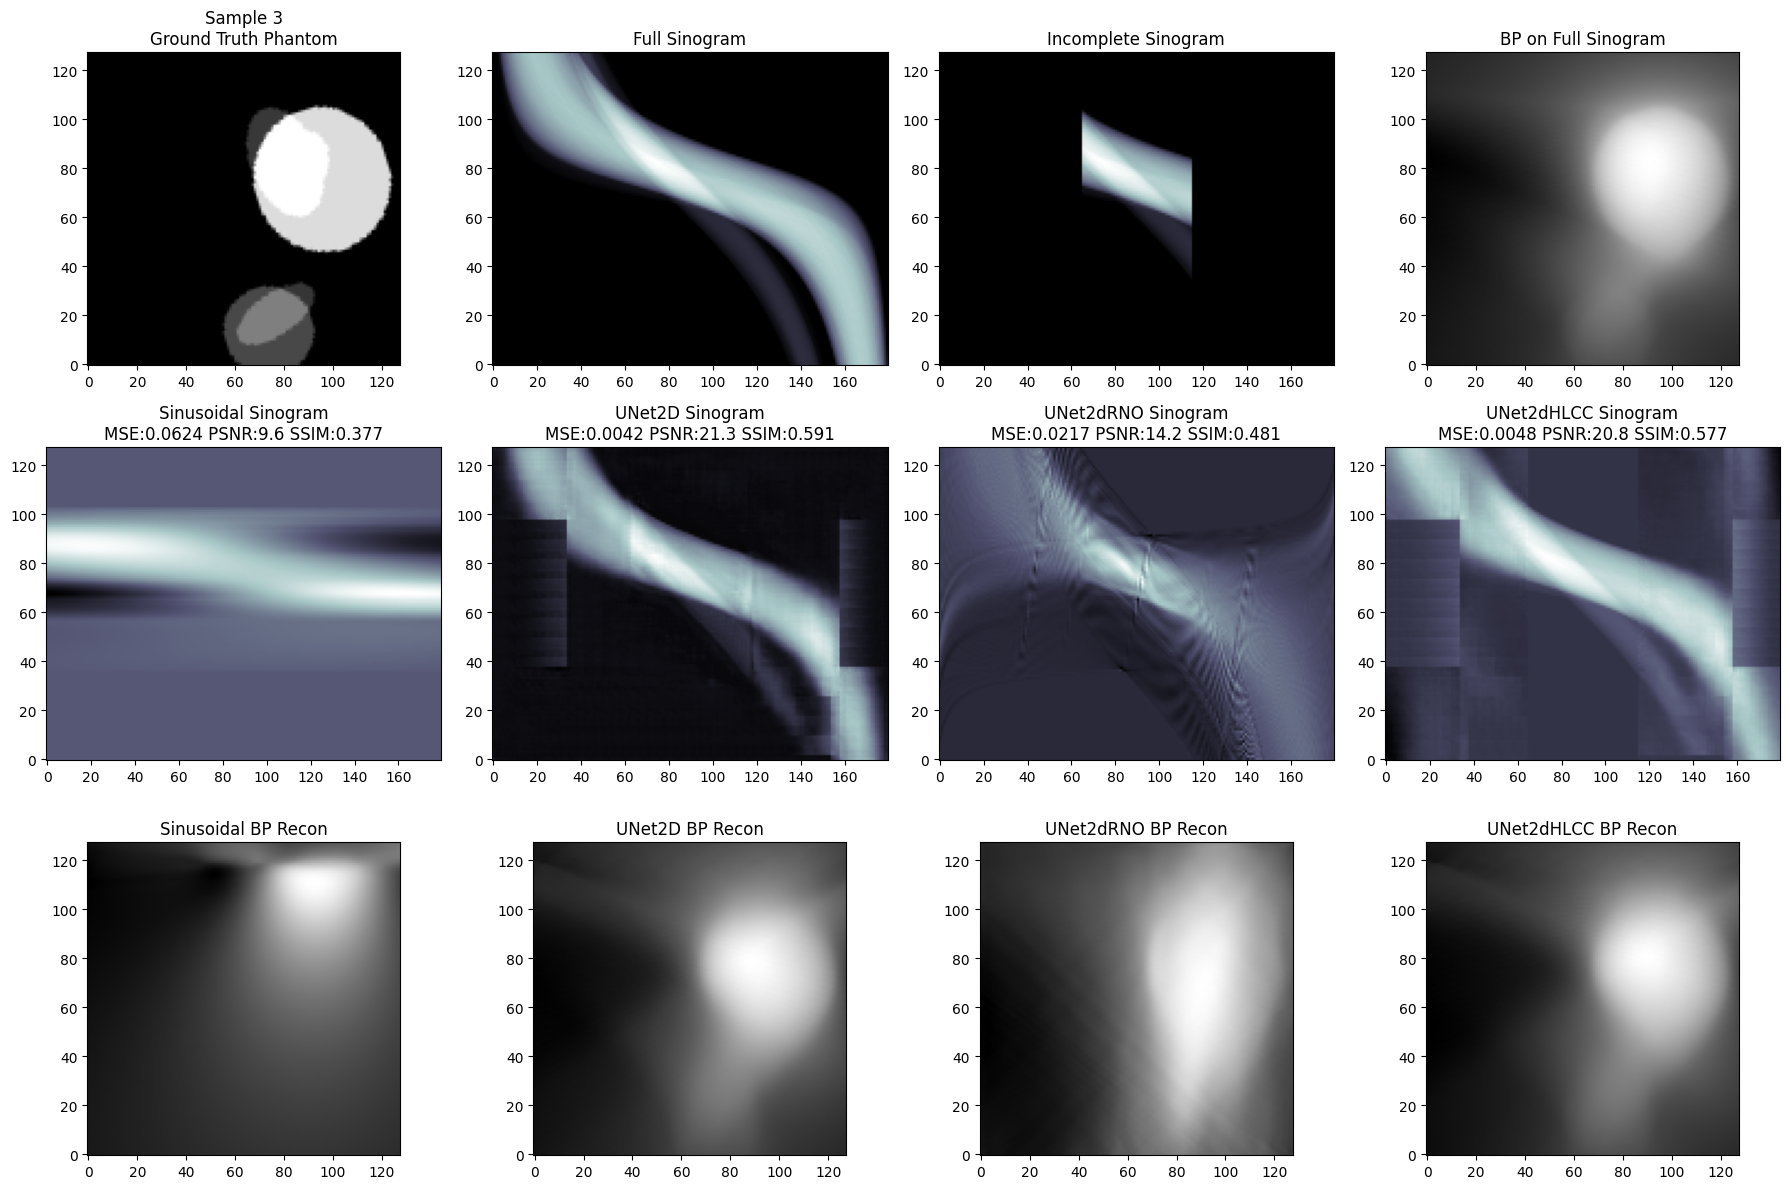

Running BP Reconstructions for Sample 4...


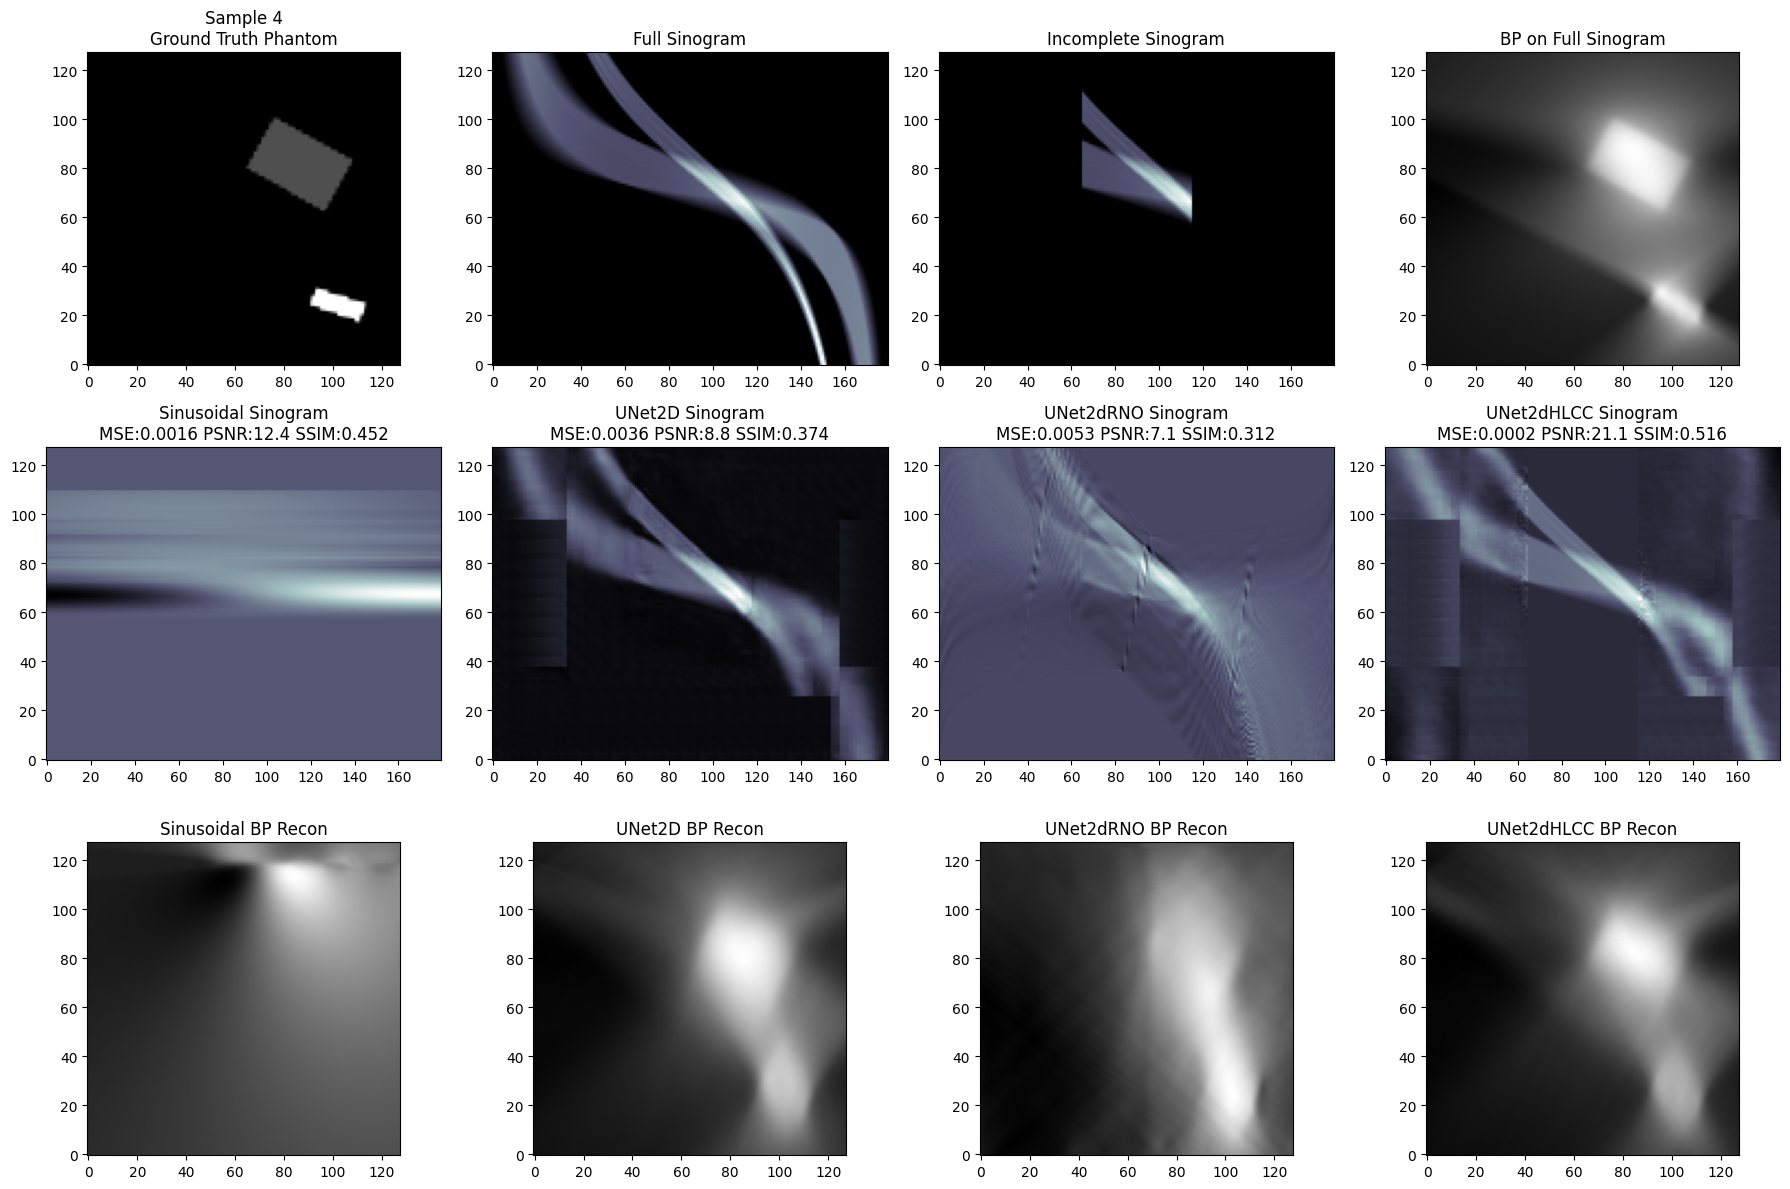

Running BP Reconstructions for Sample 5...


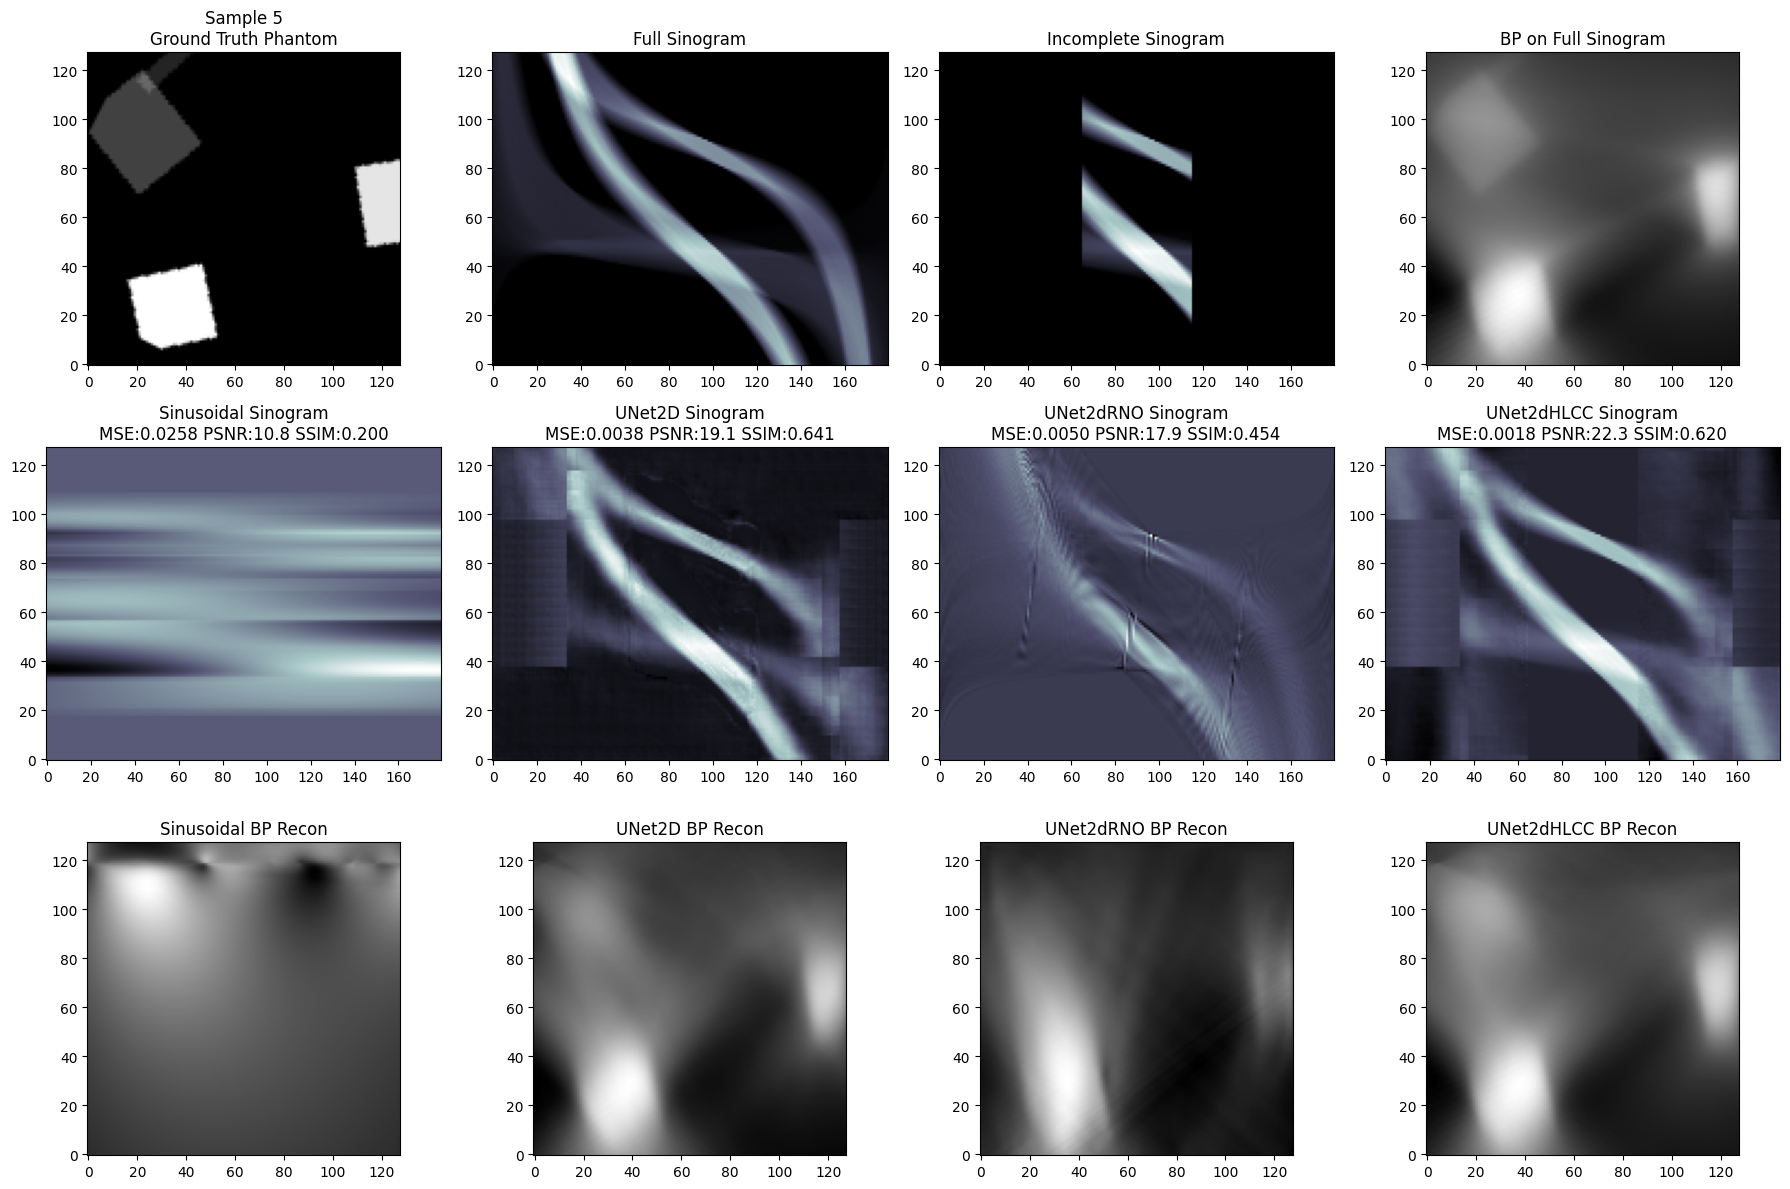

Running BP Reconstructions for Sample 6...


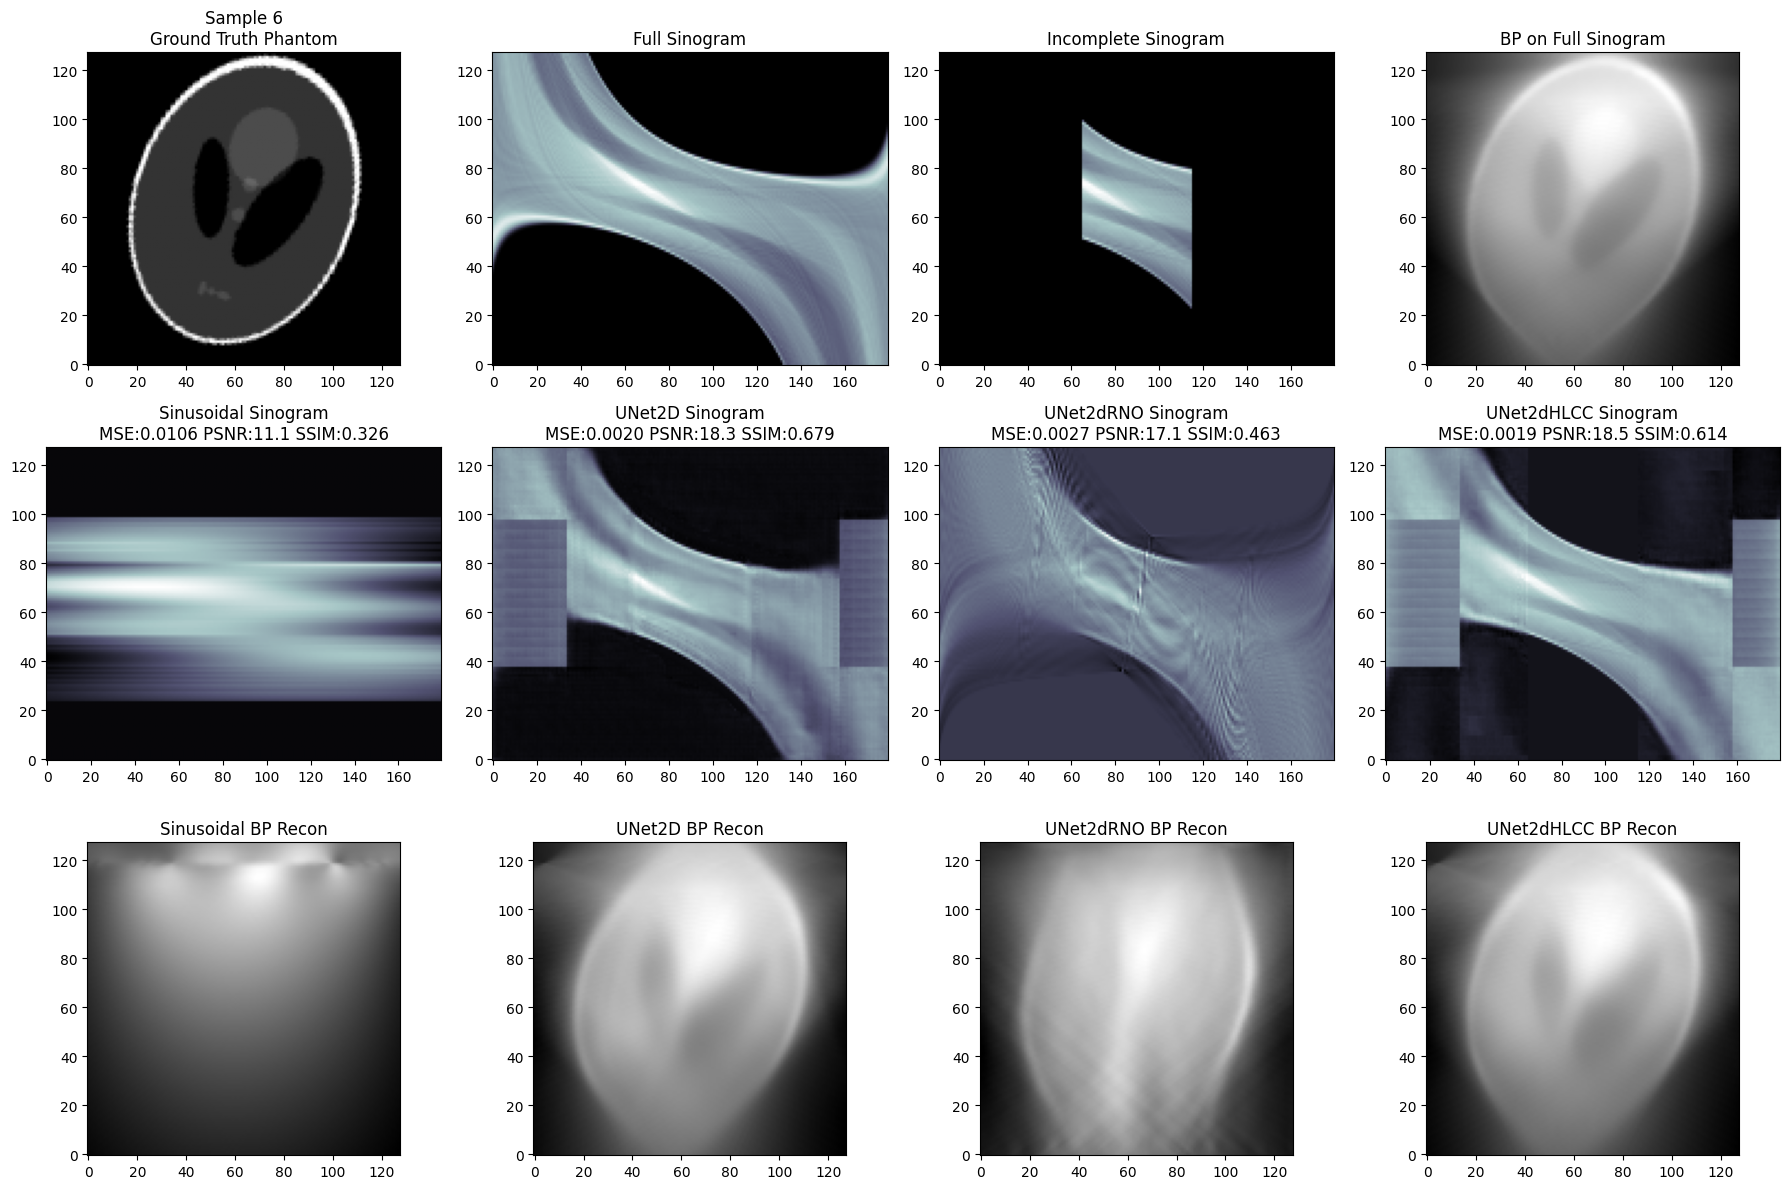

Running BP Reconstructions for Sample 7...


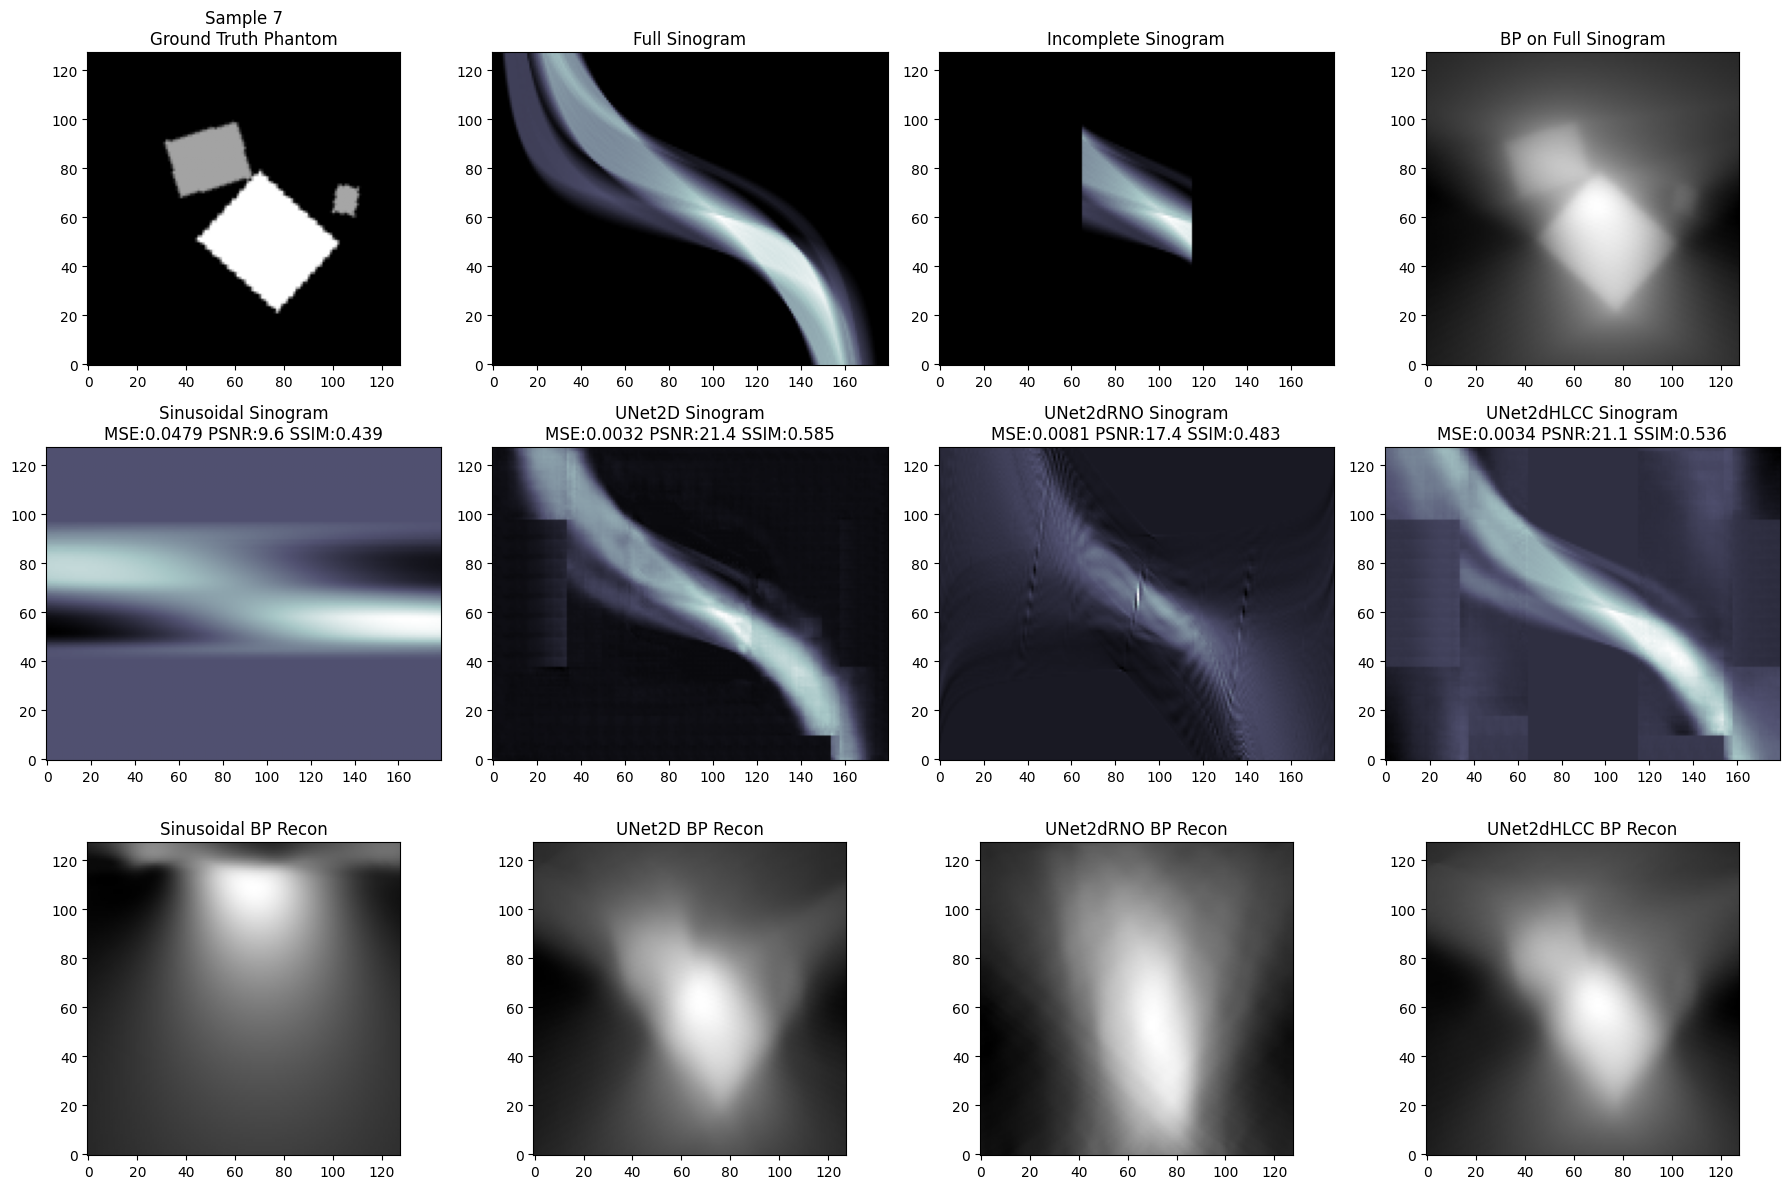

Running BP Reconstructions for Sample 8...


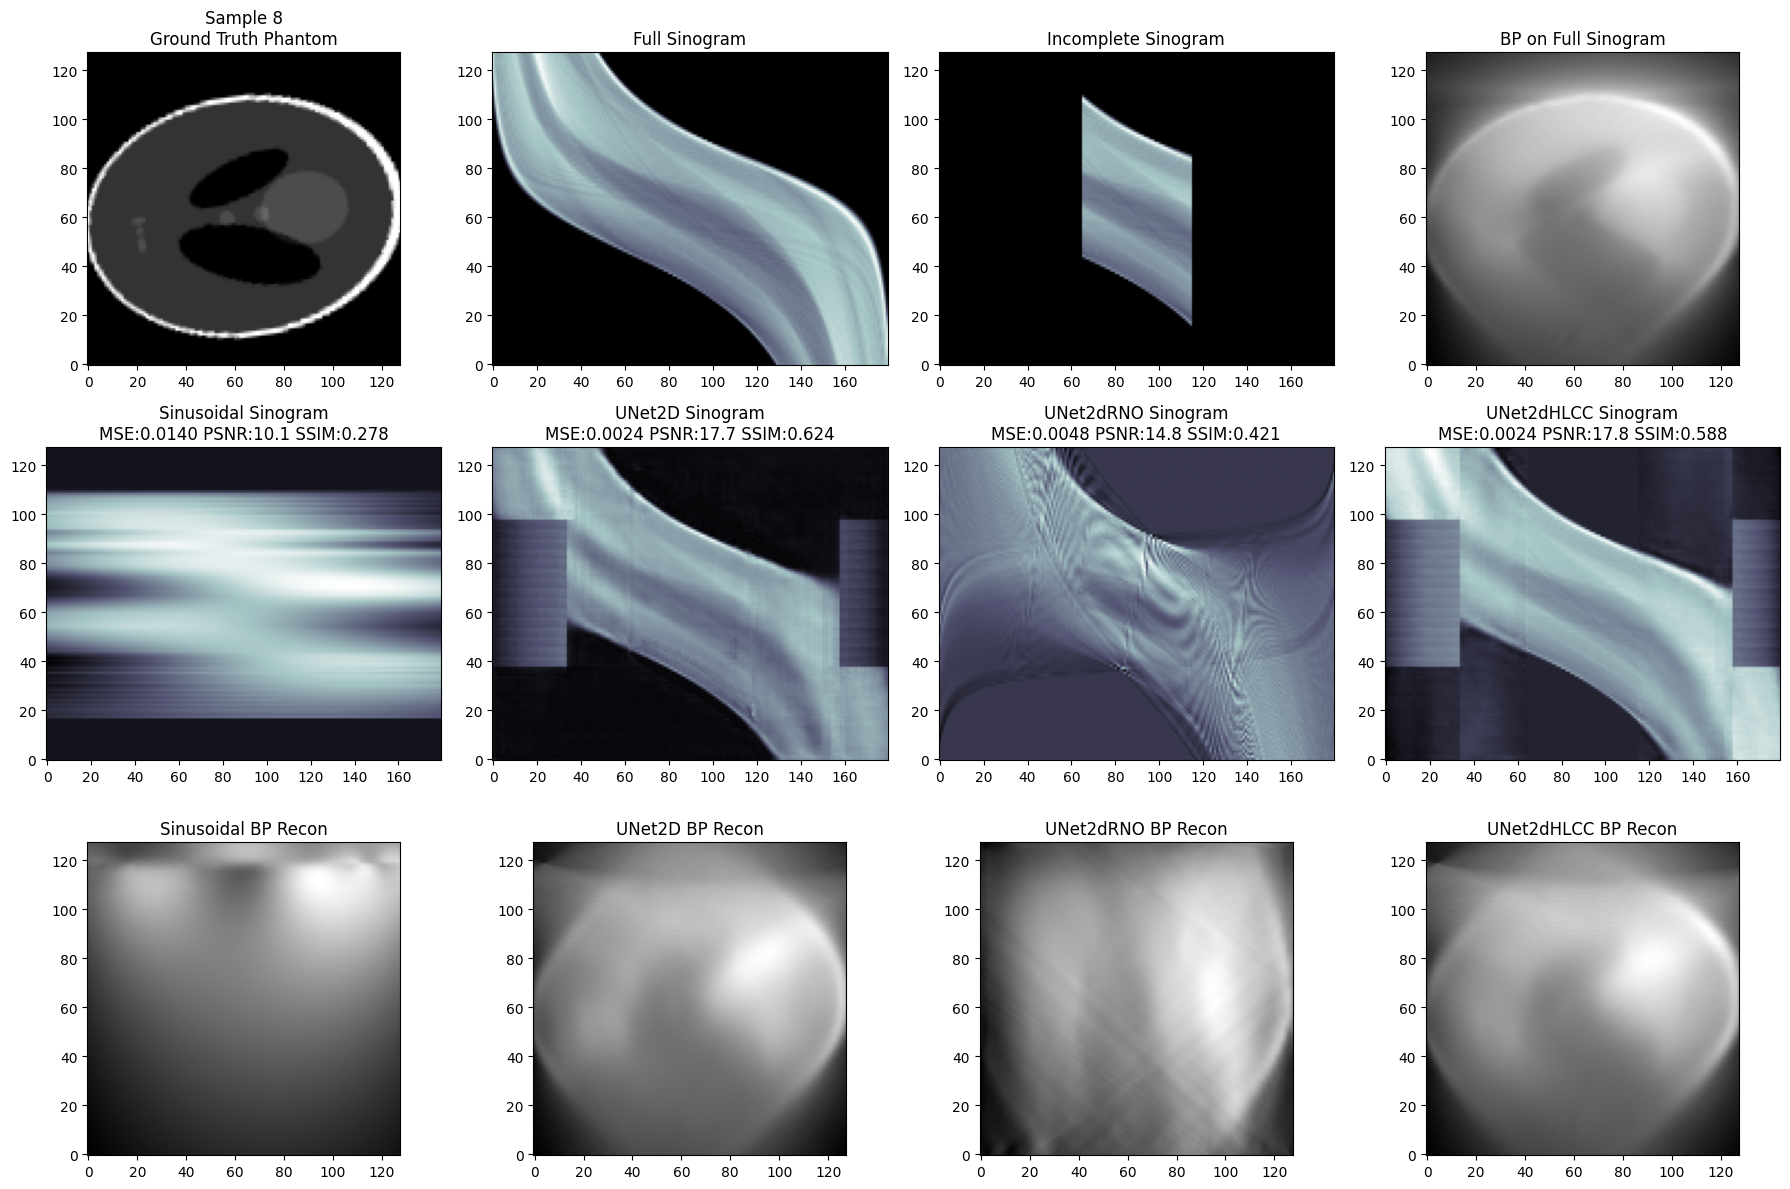

Running BP Reconstructions for Sample 9...


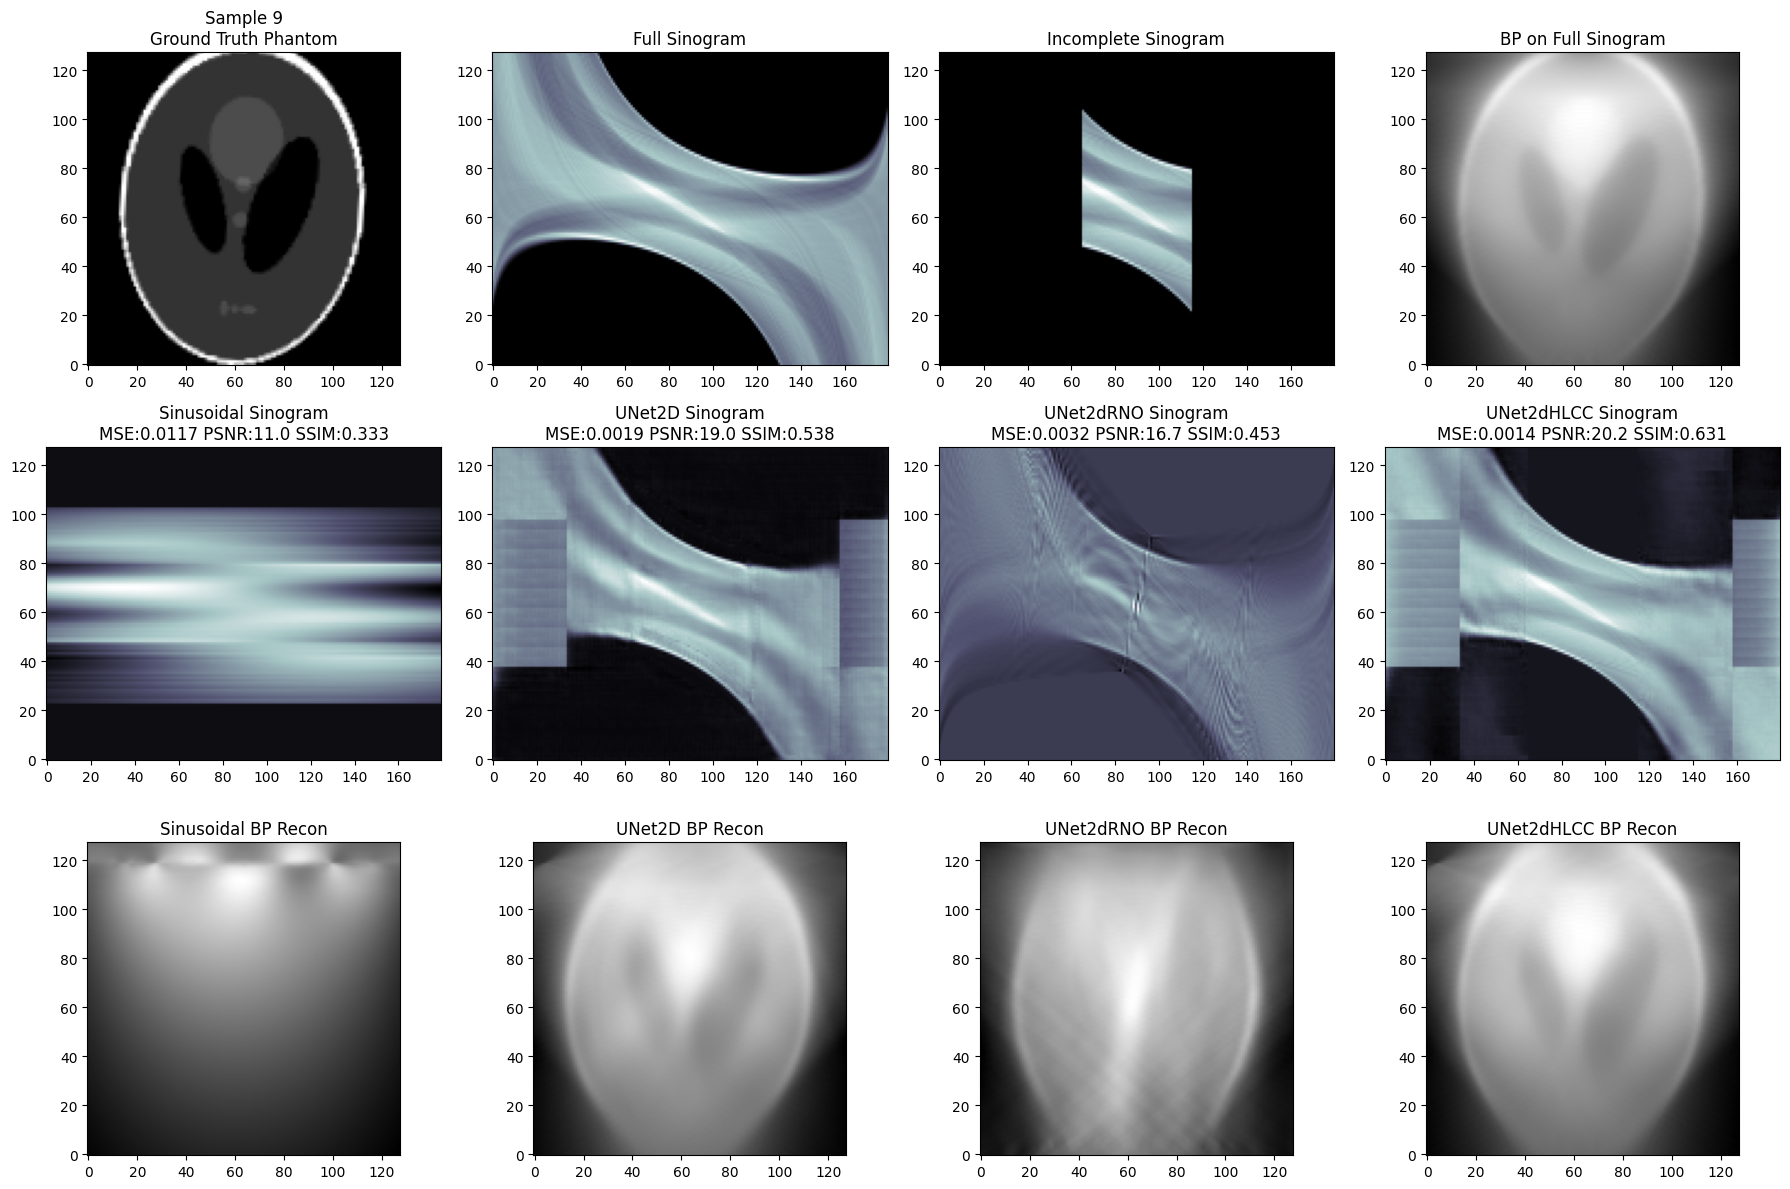

Running BP Reconstructions for Sample 10...


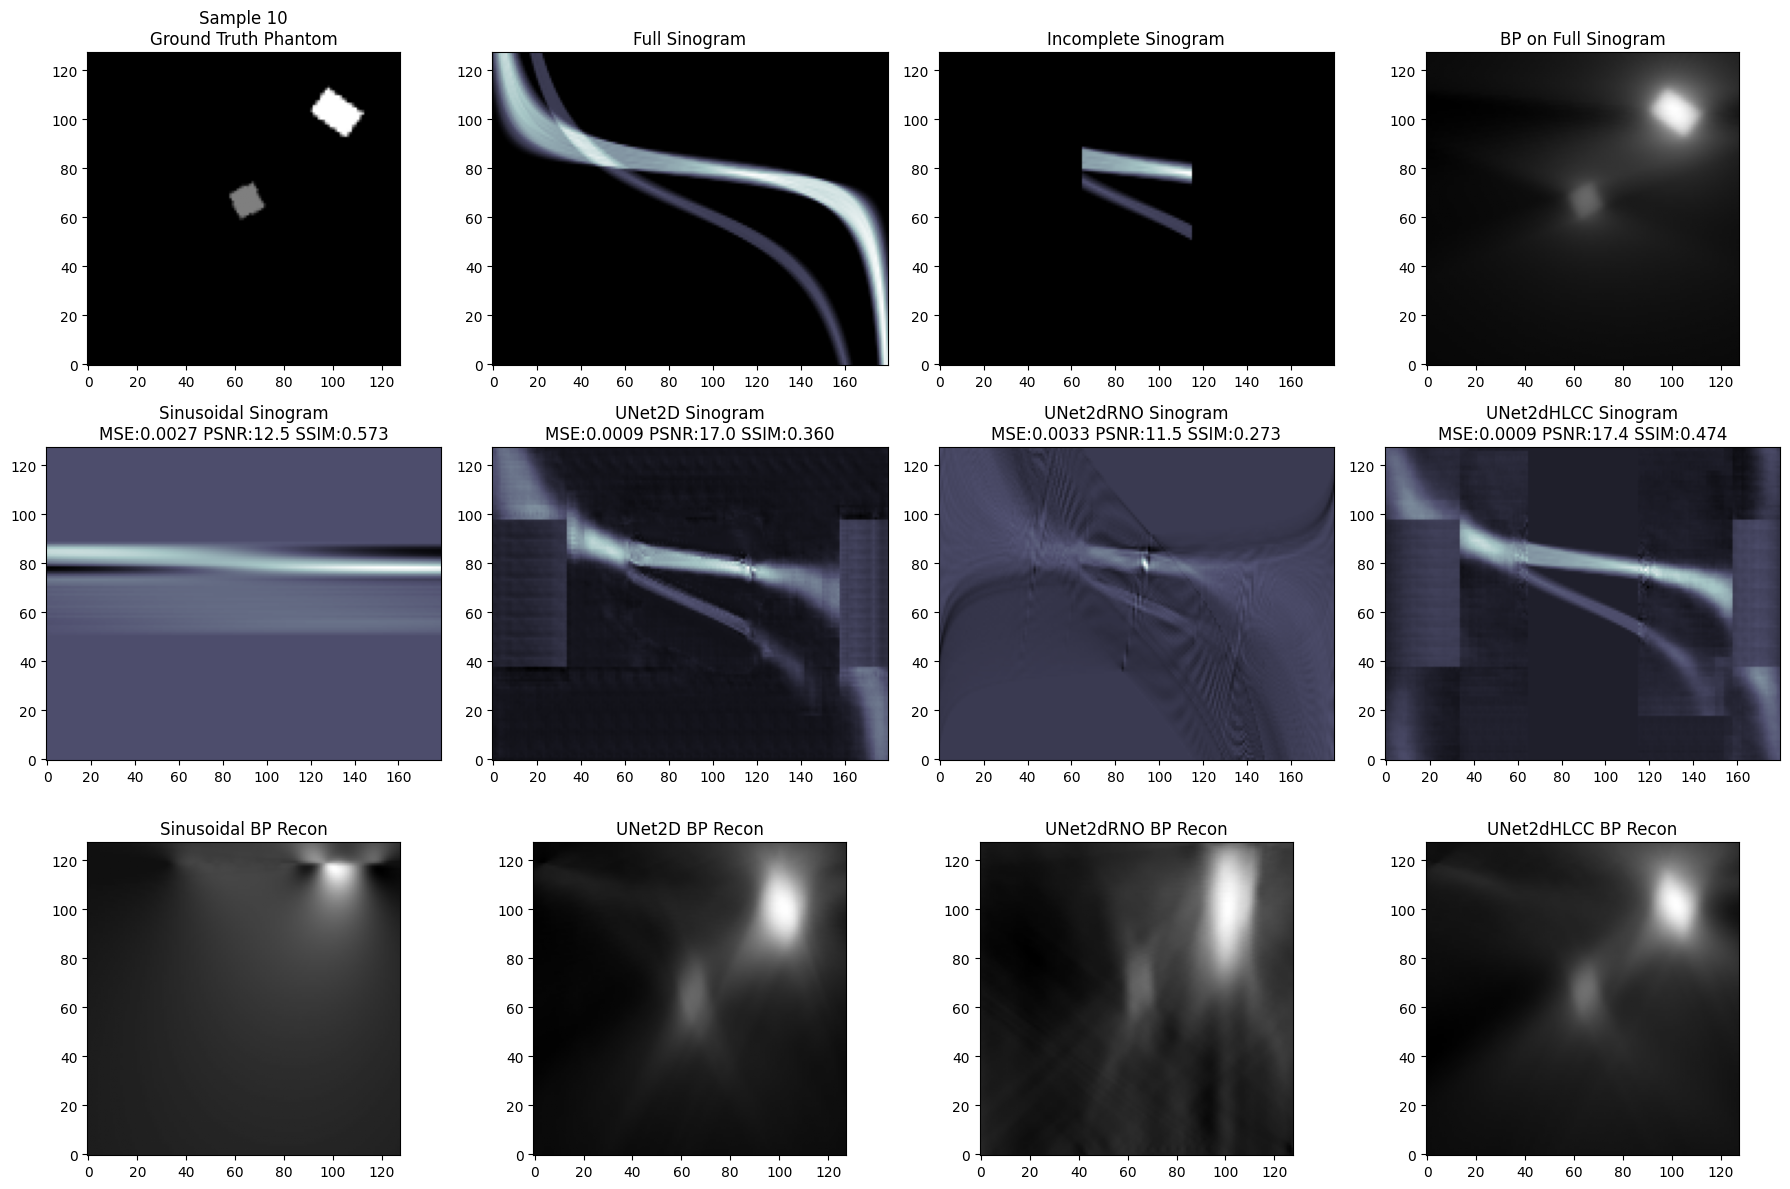

In [73]:


try:
    dataset = SinogramCompletionDataset(n_samples=10, is_validation_or_test=True)
    geometry = DBTGeometryConfig()
    
    # Generate 10 samples to visualize
    num_views = geometry.full_angles.shape[0]
    in_window = (np.rad2deg(geometry.full_angles) >= geometry.angle_min_deg) & (np.rad2deg(geometry.full_angles) <= geometry.angle_max_deg)
    acquired_mask_1d = torch.zeros(num_views, device=device)
    acquired_mask_1d[in_window] = 1.0
    acquired_mask = acquired_mask_1d.view(1, 1, num_views, 1)

    for i in range(10):
        incomplete, full, phantom = dataset[i]
        incomplete_batch = incomplete.unsqueeze(0).to(device)
        
        # Predict with all available models
        predictions = {}
        with torch.no_grad():
            for name, model in models.items():
                if name == 'UNet2dHLCC':
                    predictions[name] = model(incomplete_batch, acquired_mask).squeeze(0).squeeze(0).cpu().numpy()
                else:
                    predictions[name] = model(incomplete_batch).squeeze(0).squeeze(0).cpu().numpy()
                
        # Get ASTRA geometries for BP
        proj_geom, vol_geom = build_full_astra_geometries(geometry, (phantom.shape[1], phantom.shape[2]))
        
        # Run BP reconstructions (*100 multiplier as done in evaluate_2d.py)
        print(f"Running BP Reconstructions for Sample {i+1}...")
        full_bp = reconstruct_volume_fbp(full.squeeze(0).cpu().numpy() * 100.0, proj_geom, vol_geom)
        inc_bp = reconstruct_volume_fbp(incomplete.squeeze(0).cpu().numpy() * 100.0, proj_geom, vol_geom)
        
        bps = {}
        for name, pred in predictions.items():
            bps[name] = reconstruct_volume_fbp(pred * 100.0, proj_geom, vol_geom)
        
        # Plotting - 3 Rows: Reference, Sinograms, BP
        num_cols = max(4, len(predictions))
        fig, axes = plt.subplots(3, num_cols, figsize=(4.5 * num_cols, 12))
        
        # ROW 1: References
        axes[0, 0].imshow(phantom.squeeze(0).cpu().numpy(), cmap='gray', origin='lower')
        axes[0, 0].set_title(f"Sample {i+1}\nGround Truth Phantom")
        
        axes[0, 1].imshow(full.squeeze(0).cpu().numpy().T, cmap='bone', origin='lower', aspect='auto')
        axes[0, 1].set_title("Full Sinogram")
        
        axes[0, 2].imshow(incomplete.squeeze(0).cpu().numpy().T, cmap='bone', origin='lower', aspect='auto')
        axes[0, 2].set_title("Incomplete Sinogram")
        
        if full_bp is not None:
            axes[0, 3].imshow(full_bp, cmap='gray', origin='lower')
            axes[0, 3].set_title("BP on Full Sinogram")
        else:
            axes[0, 3].set_title("ASTRA not available")
            
        for j in range(4, num_cols):
            axes[0, j].axis('off')
        
        from skimage.metrics import mean_squared_error as mse
        from skimage.metrics import peak_signal_noise_ratio as psnr
        from skimage.metrics import structural_similarity as ssim
        
        full_np = full.squeeze(0).cpu().numpy()
        
        # ROW 2: Model Sinograms
        ax_idx = 0
        for name, pred in predictions.items():
            axes[1, ax_idx].imshow(pred.T, cmap='bone', origin='lower', aspect='auto')
            m = mse(full_np, pred)
            p = psnr(full_np, pred, data_range=full_np.max() - full_np.min())
            s = ssim(full_np, pred, data_range=full_np.max() - full_np.min())
            axes[1, ax_idx].set_title(f"{name} Sinogram\nMSE:{m:.4f} PSNR:{p:.1f} SSIM:{s:.3f}")
            ax_idx += 1
        for j in range(ax_idx, num_cols):
            axes[1, j].axis('off')
            
        # ROW 3: Model BP Reconstructions
        ax_idx = 0
        for name, reco in bps.items():
            if reco is not None:
                axes[2, ax_idx].imshow(reco, cmap='gray', origin='lower')
                axes[2, ax_idx].set_title(f"{name} BP Recon")
            else:
                axes[2, ax_idx].set_title("ASTRA not available")
            ax_idx += 1
        for j in range(ax_idx, num_cols):
            axes[2, j].axis('off')
            
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"An error occurred during dataset loading or visualization: {e}")


# ## SinoSheavesNN Analysis
# 
# In this section, we evaluate the Physics-Informed **Sheaf Neural Network (SNN)** architecture. 
# The SNN natively respects the rotational symmetries of the Radon transform by passing features through $SO(2)$ restriction maps, while the Helgason-Ludwig moments constrain the mass and center of mass of the predictions.
# 
# Below, we load the model, perform a forward pass, compute the physical consistency metrics, and visualize the predicted sinogram.

In [74]:


import torch
import matplotlib.pyplot as plt
import numpy as np
from src_2D.conf.geometry_conf_2d import DBTGeometryConfig
from src_2D.geometry.dbt_geometry_2d import DBTGeometry
from src_2D.data.dataset_2d import SinogramCompletionDataset
from src_2D.models.SinoSheavesNN.snn_model import SinoSheafNet
from src_2D.models.SinoSheavesNN.graph_data import create_sinogram_data
from src_2D.models.SinoSheavesNN.physics_loss import HelgasonLudwigLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = DBTGeometryConfig()
geom = DBTGeometry(
    angles=config.full_angles,
    src_radius=config.src_radius_mm,
    det_radius=config.det_radius_mm,
    det_col_count=config.det_col_count,
    det_pixel_size=config.det_pixel_size_mm,
)

# 1. Load Dataset
dataset = SinogramCompletionDataset(n_samples=5, geometry_config=config, device=str(device), is_validation_or_test=True)

# 2. Initialize Model
# NOTE: Update the hyperparameters based on your best Optuna trial!
# 2. Initialize Model
model_path = project_root / "outputs" / "2d" / "checkpoints" / "best_snn_model.pt"
model = SinoSheafNet(num_stalks=8, num_layers=6).to(device)

if model_path.exists():
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Loaded trained SinoSheavesNN model.")

model = SinoSheafNet(num_stalks=8, num_layers=6).to(device)
if model_path.exists():
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Loaded trained SinoSheavesNN model.")
else:
    print("Warning: Pre-trained weights not found. Using untrained model for demonstration.\nTrain the model using run_training.py to see accurate results.")

Loaded trained SinoSheavesNN model.
Loaded trained SinoSheavesNN model.


--- SinoSheavesNN Performance ---
SSIM: 0.1486
Helgason-Ludwig 0th Moment (Mass Variance): 0.0000
Helgason-Ludwig 1st Moment (Center of Mass Residual): 0.0018


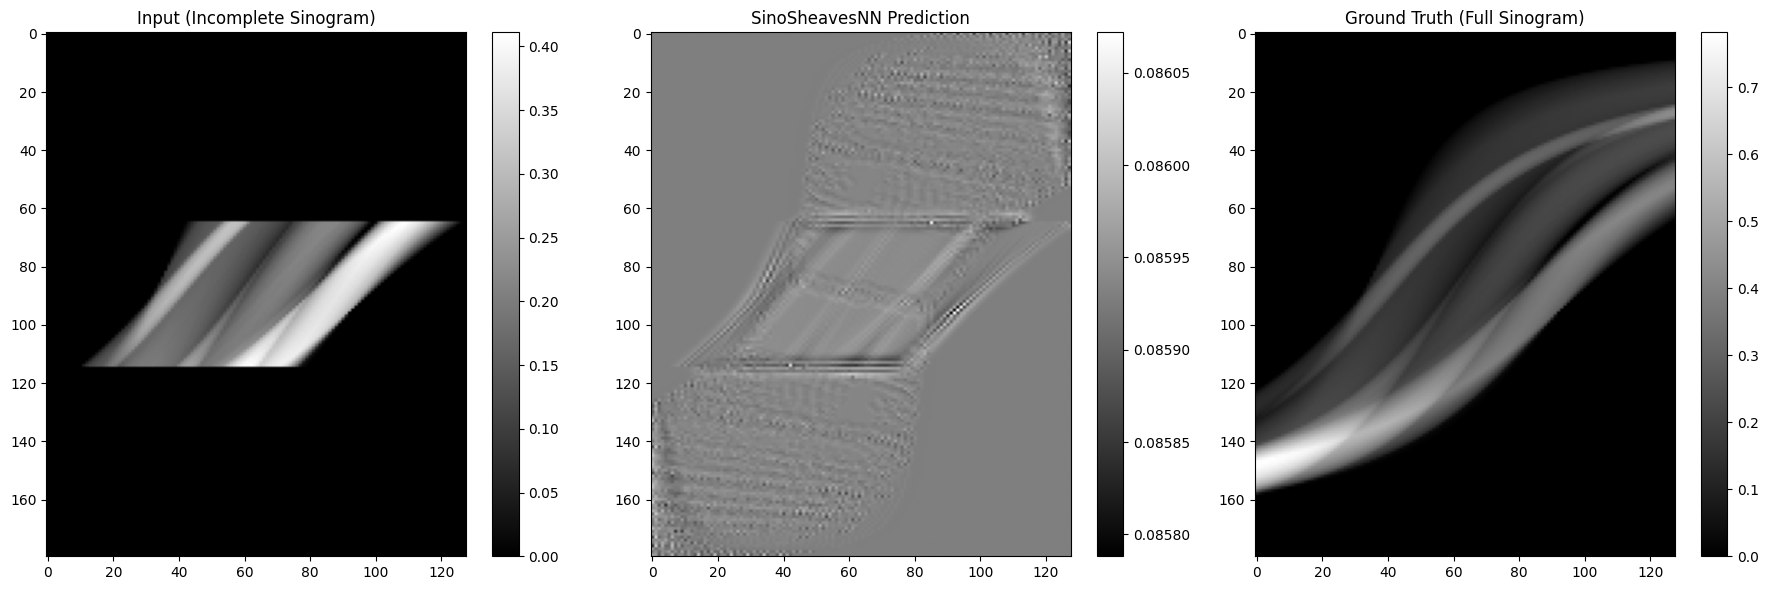

In [75]:


# 3. Qualitative Evaluation & Physics Verification
inc_sino, full_sino, phantom = dataset[0]

inc_sino_tensor = inc_sino[0].to(device)
target_sino_tensor = full_sino[0].to(device)

# Build the Graph Data dynamically
graph_data = create_sinogram_data(inc_sino_tensor, geom).to(device)

with torch.no_grad():
    out = model(graph_data)
    pred_sino = out.view(geom.num_views, geom.det_col_count)
    
# Physics Metrics
hl_loss = HelgasonLudwigLoss(geom).to(device)
m0_loss, m1_loss = hl_loss(pred_sino)

from skimage.metrics import structural_similarity as ssim
target_np = target_sino_tensor.cpu().numpy()
pred_np = pred_sino.cpu().numpy()
d_range = max(target_np.max() - target_np.min(), 1.0)
snn_ssim = ssim(target_np, pred_np, data_range=d_range)

print("--- SinoSheavesNN Performance ---")
print(f"SSIM: {snn_ssim:.4f}")
print(f"Helgason-Ludwig 0th Moment (Mass Variance): {m0_loss.item():.4f}")
print(f"Helgason-Ludwig 1st Moment (Center of Mass Residual): {m1_loss.item():.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(inc_sino_tensor.cpu().numpy(), cmap='gray', aspect='auto')
axes[0].set_title("Input (Incomplete Sinogram)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pred_np, cmap='gray', aspect='auto')
axes[1].set_title("SinoSheavesNN Prediction")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(target_np, cmap='gray', aspect='auto')
axes[2].set_title("Ground Truth (Full Sinogram)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()